# “Recommend a premium subscription (Yes/No)”

In [143]:
# import nescessary libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [144]:
#load the dataset
data = pd.read_csv('/content/customer_recommendation_dataset.csv')

In [145]:
data.shape

(2000, 7)

In [146]:
data.sample(5)

,age,gender,city,income,spending_score,membership_years,recommend
1928,35,Female,Mumbai,71658,19,5.5,Yes
145,30,Female,Hyderabad,104762,47,9.7,Yes
1163,38,Female,Bangalore,106006,84,4.0,Yes
132,31,Male,Chennai,144011,23,5.4,Yes
1688,44,Male,Mumbai,126300,61,8.5,Yes


In [147]:
data.isnull().sum()

,0
age,0
gender,0
city,0
income,0
spending_score,0
membership_years,0
recommend,0


In [148]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               2000 non-null   int64  
 1   gender            2000 non-null   object 
 2   city              2000 non-null   object 
 3   income            2000 non-null   int64  
 4   spending_score    2000 non-null   int64  
 5   membership_years  2000 non-null   float64
 6   recommend         2000 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 109.5+ KB


In [149]:
data.duplicated().sum()

np.int64(0)

In [150]:
data.describe()

,age,income,spending_score,membership_years
count,2000.00000,2000.000000,2000.000000,2000.000000
mean,41.31650,84391.476000,50.019500,5.131650
std,13.46566,37964.676633,28.696164,2.725237
min,18.00000,20060.000000,1.000000,0.500000
25%,30.00000,50445.250000,25.000000,2.800000
50%,42.00000,85766.000000,50.000000,5.100000
75%,53.00000,118027.250000,75.000000,7.400000
max,64.00000,149900.000000,99.000000,10.000000


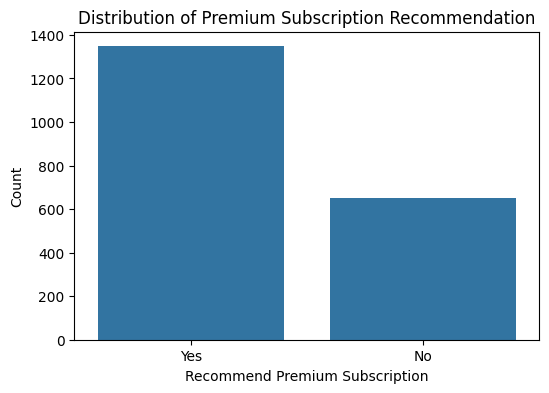

In [151]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='recommend')
plt.title('Distribution of Premium Subscription Recommendation')
plt.xlabel('Recommend Premium Subscription')
plt.ylabel('Count')
plt.show()


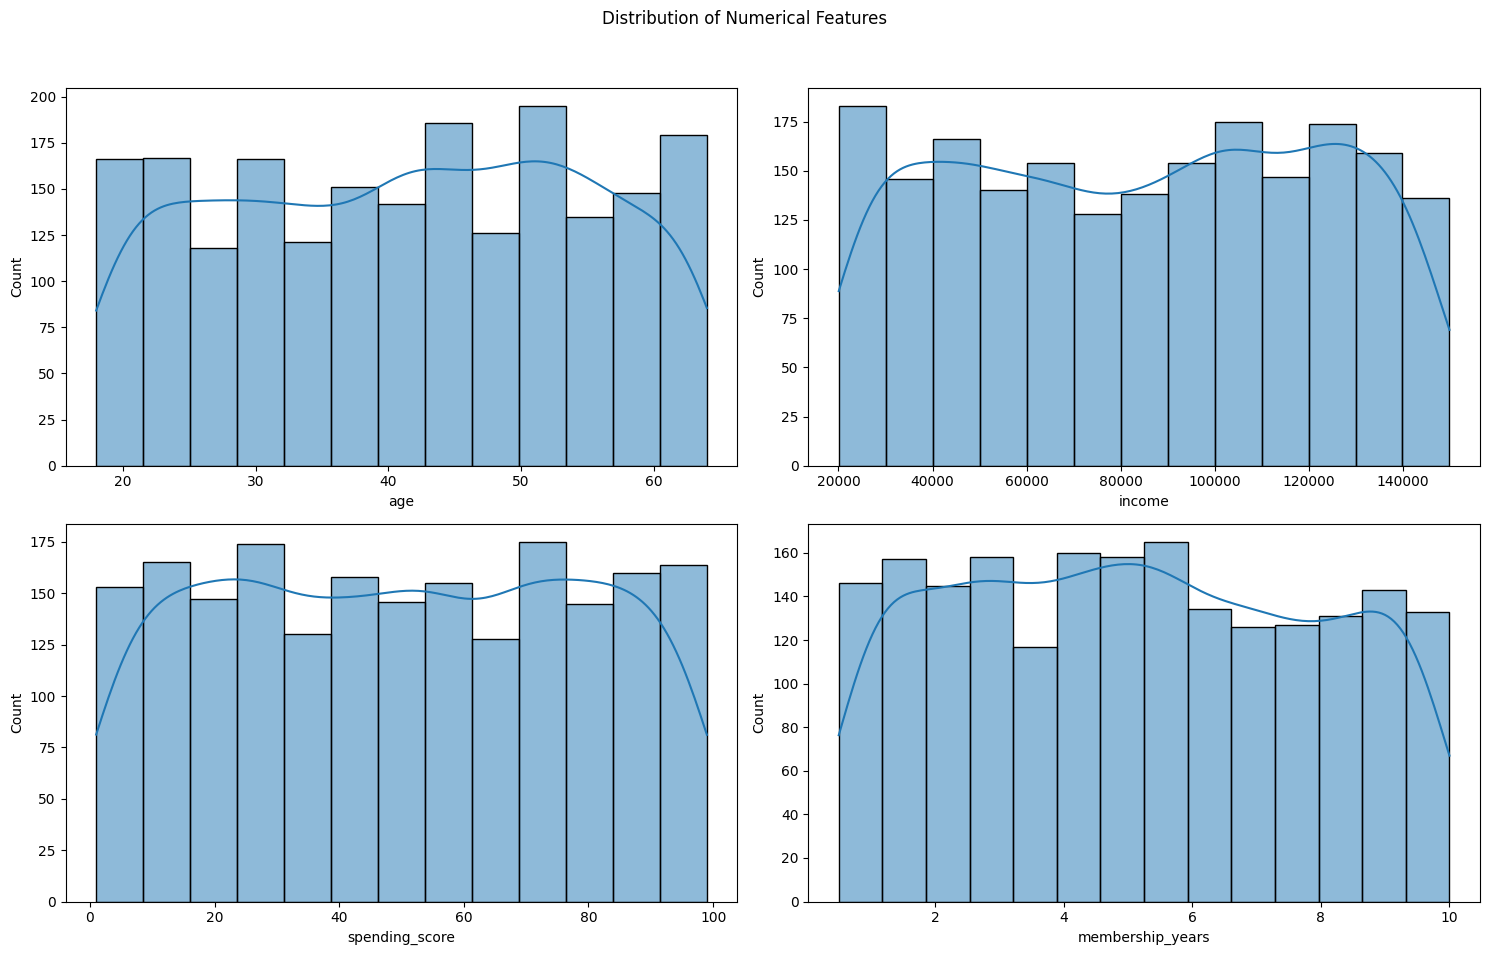

In [152]:
# Distribution of numerical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Features')
sns.histplot(data['age'], kde=True, ax=axes[0, 0])
sns.histplot(data['income'], kde=True, ax=axes[0, 1])
sns.histplot(data['spending_score'], kde=True, ax=axes[1, 0])
sns.histplot(data['membership_years'], kde=True, ax=axes[1, 1])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

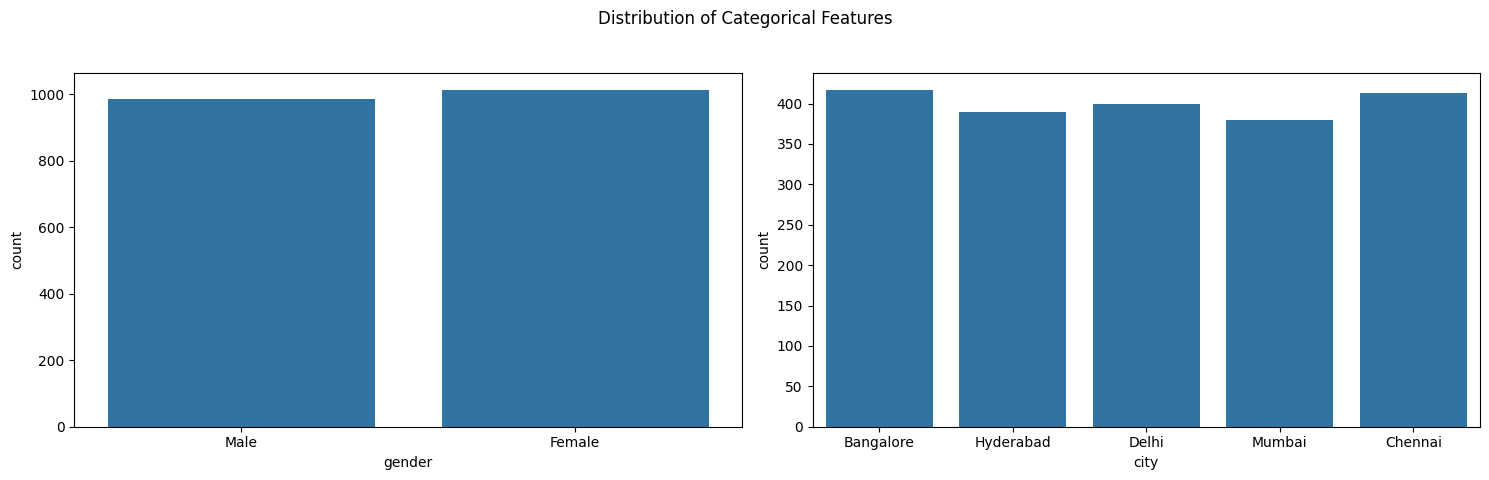

In [153]:
# Distribution of categorical features
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Distribution of Categorical Features')
sns.countplot(data=data, x='gender', ax=axes[0])
sns.countplot(data=data, x='city', ax=axes[1])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [154]:
data.head()

,age,gender,city,income,spending_score,membership_years,recommend
0,56,Male,Bangalore,101326,53,4.7,Yes
1,46,Male,Hyderabad,32205,48,5.1,No
2,32,Male,Hyderabad,140243,7,7.9,Yes
3,60,Male,Delhi,109874,59,4.1,No
4,25,Female,Bangalore,32748,69,4.7,Yes


In [155]:
new_data = data.copy()

In [156]:
new_data.columns = new_data.columns.str.lower().str.strip().str.replace(' ','_')

In [157]:
new_data

,age,gender,city,income,spending_score,membership_years,recommend
0,56,Male,Bangalore,101326,53,4.7,Yes
1,46,Male,Hyderabad,32205,48,5.1,No
2,32,Male,Hyderabad,140243,7,7.9,Yes
3,60,Male,Delhi,109874,59,4.1,No
4,25,Female,Bangalore,32748,69,4.7,Yes
...,...,...,...,...,...,...,...
1995,42,Female,Chennai,126031,98,6.4,Yes
1996,37,Female,Chennai,133682,46,6.6,Yes
1997,19,Female,Chennai,54565,22,0.8,Yes
1998,56,Female,Bangalore,120435,11,8.4,Yes


In [194]:
data['membership_years'].max()

10.0

In [158]:
# data['recommend'] = data['recommend'].map({'No': 0, 'Yes': 1})
# data['city'].value_counts()

In [187]:
#importing sklearn stuff

from sklearn.preprocessing import LabelEncoder , OneHotEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import chi2 ,SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import joblib

In [188]:
X = new_data.drop('recommend',axis=1)
y = new_data['recommend']

# Encode target variable y
label_encoder_y = LabelEncoder()
y = pd.Series(label_encoder_y.fit_transform(y))

# Creating the column transformer for numerical and categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'income', 'spending_score', 'membership_years']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['gender', 'city'])
    ],
    remainder='passthrough' # Keep other columns if any, or drop them if not needed
)

# PCA step
pca_step = PCA(n_components=5)

# Classifier step
classifier = RandomForestClassifier(random_state=42)

# Create the full pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('pca', pca_step),
                           ('classifier', classifier)])

print("Pipeline created successfully!")

Pipeline created successfully!


In [189]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

In [190]:
pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully!")

Pipeline fitted successfully!


In [191]:
y_pred = pipeline.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[406 111]
 [112 971]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78       517
           1       0.90      0.90      0.90      1083

    accuracy                           0.86      1600
   macro avg       0.84      0.84      0.84      1600
weighted avg       0.86      0.86      0.86      1600



In [192]:
joblib.dump(pipeline, 'model.pkl')
print("Model exported as model.pkl")

Model exported as model.pkl
